# Tarea 2 Ciencia de redes
Profesor: Wenceslao Palma

Alumna: Antonia Luengo

# Problema 1

## a) Redacte un resumen de los principales puntos del paper.


**Problema**

En sociedad, nuestras decisiones suelen estar influenciadas por lo que observamos del resto. El problema, es que muy pocas veces tenemos una visión completa de lo que pasa de forma global, si no que nos guiamos por lo que vemos en nuestro círculo cercano. Es por esto que la forma en que estamos conectados puede distorsionar totalmente nuestra realidad, creando el llamado "espejismo de la mayoría". En resumen, algo que puede ser muy raro a nivel global, parece ser lo normal porque lo vemos mucho en nuestros conocidos. Esto hace que creamos que algo es tendencia cuando no lo es, acelerando el contagio social.


**Métodos**

Se usó un modelo implementado por SNAP que se probó tanto en redes artificiales como con datos reales. Se trabajó con modelos de redes (como escala libre y redes aleatorias) para jugar con la estructura y ver como cambiaba la percepción al conectar distintos tipos de usuarios o cambiar la correlación entre ellos. También se analizaron datos de redes sociales de verdad, como Twitter, redes de colaboración científica, correos electrónicos y blogs de política, para ver si este efecto se repetía fuera de un entorno controlado.


**Resultados**

Los resultados muestran que este espejismo se vuelve mucho más fuerte por tres cosas: cuando la red es heterogénea (pocos nodos con muchas conexiones), tiene una estructura disasortativa (populares se conectan con impopulares), y una correlación positiva entre grado y atributo (nodos activos están súper conectados). 

Se observó en redes de escala libre altamente heterogéneas que teniendo un 5% de nodos activos, entre el 60% y 80% de la red percibe que la mayoría de sus vecinos son activos.

En redes reales el efecto fue mucho mas pronunciado en estructuras disasortativas, donde los hubs se conectan con nodos de bajo grado bombardeando su percepción local.

**Conclusiones**

Al final, todo esto explica por qué a veces caemos en sesgos como el "falso consenso" o la "ignorancia pluralista", donde creemos que todos piensan igual cuando no es así. El problema de fondo es el poder enorme que tienen estos hubs o usuarios súper conectados para distorsionar la visión de sus vecinos. Como ellos aparecen en todos lados, nos hacen creer que su realidad es la de todos. Esto significa que hay estructuras de red que son mucho más fáciles de manipular y donde las opiniones pueden cambiar de golpe solo por este efecto visual de la red.

# Problema 2

## a) Explique el “conﬁguration model” utilizado en el paper. A su juicio, es el mejor modelo generador de redes para este paper?


El Configuration Model es un método algorítmico que usaron los autores para construir redes sintéticas de escala libre con una secuencia de grados ya definida. 

Primero definen cuantos enlaces (half-edges) tendrá cada nodo siguiendo la ley de potencia. Luego el modelo va uniendo los pares de los medios enlaces al azar hasta formar una arista completa. Esto se repite hasta que ya no quedan medios enlaces o ya no se pueden formar más conexiones.

Lo bueno de este modelo, es que pueden crear redes con una distribución de grados muy heterogénea, perfecto para crear el efecto del espejismo.

A mi juicio, este modelo si es el más adecuado para demostrar el efecto del espejismo de la mayoría, ya que se pueden controlar variables como la distribución de los grados y se puede cambiar la asortatividad sin alterar la distribución original. También estas redes simuladas son muy parecidas a redes reales como Twitter, blogs políticos, etc, donde los hubs dominan la percepción local de los demás. Los autores mencionaron que probaron con el modelo de Erdos-Renyi, pero al generar redes mas homogéneas el espejismo es más débil. 

## b) Replique los experimentos realizados con redes generadas sintéticamente. Concluya.

### Configuración Entorno

In [34]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import random
from tqdm import tqdm

N = 10000
p_active = 0.05
alphas = [2.1, 2.4, 3.1]

### Generación Red Libre Escala

In [35]:
def generate_scale_free_network(N, alpha):
    s = np.zeros(N, dtype=int)
    for i in range(N):
        while True:
            d = np.random.zipf(alpha)
            if 0 < d < N:
                s[i] = d
                break
                
    if sum(s) % 2 != 0:
        s[0] += 1
        
    G = nx.configuration_model(s)
    G.remove_edges_from(list(nx.selfloop_edges(G)))
    
    return G

In [36]:
def generate_erdos_renyi_network(N, mean_k):
    # En un Erdos-Rényi, p es la probabilidad de conexión
    p = mean_k / (N - 1)
    G = nx.erdos_renyi_graph(N, p)
    
    # Extraer la componente gigante
    components = sorted(nx.connected_components(G), key=len, reverse=True)
    G = G.subgraph(components[0]).copy()
    
    grado_promedio_real = (2 * G.number_of_edges()) / G.number_of_nodes()
    print(f"Red Erdős-Rényi generada (<k>={mean_k}):")
    print(f" -> Grado prom. real: {grado_promedio_real:.2f}")
    
    return G

In [37]:
def assign_initial_attributes(G, p_active):
    nodes = list(G.nodes())
    num_active = int(len(nodes) * p_active)
    nx.set_node_attributes(G, 0, 'x')
    active_nodes = random.sample(nodes, num_active)
    for n in active_nodes:
        G.nodes[n]['x'] = 1

def calculate_rhokx(G):
    k = np.array([d for n, d in G.degree()])
    x = np.array([d['x'] for n, d in G.nodes(data=True)])
    sigma_k = np.std(k)
    sigma_x = np.std(x)
    if sigma_x == 0 or sigma_k == 0:
        return 0.0
    P_x1 = np.mean(x)
    mean_k = np.mean(k)
    k_x1 = k[x == 1]
    mean_k_x1 = np.mean(k_x1) if len(k_x1) > 0 else 0
    return (P_x1 / (sigma_x * sigma_k)) * (mean_k_x1 - mean_k)

### Algoritmos de Manipulación

In [38]:
def attribute_swapping(G, target_rho, max_steps=50000, tol=0.01):
    active_set = set(n for n, attr in G.nodes(data=True) if attr['x'] == 1)
    inactive_set = set(G.nodes()) - active_set
    active_list = list(active_set)
    inactive_list = list(inactive_set)
    
    degree_dict = dict(G.degree())
    current_rho = calculate_rhokx(G)
    
    if abs(current_rho - target_rho) < tol:
        return current_rho

    # Cálculo de constante de proporcionalidad (C_rho) para actualización O(1)
    nodes_list = list(G.nodes())
    k_array = np.array([degree_dict[n] for n in nodes_list])
    x_array = np.array([G.nodes[n]['x'] for n in nodes_list])
    
    sigma_k = np.std(k_array)
    sigma_x = np.std(x_array)
    if sigma_k == 0 or sigma_x == 0: return 0.0
    
    P_x1 = np.mean(x_array)
    # rho es lineal respecto a la suma de los grados de los nodos activos
    C_rho = P_x1 / (sigma_x * sigma_k * len(active_list))

    for step in range(max_steps):
        if abs(current_rho - target_rho) < tol:
            break
            
        idx_a = random.randrange(len(active_list))
        idx_i = random.randrange(len(inactive_list))
        v_active = active_list[idx_a]
        v_inactive = inactive_list[idx_i]
        
        k_a = degree_dict[v_active]
        k_i = degree_dict[v_inactive]
        
        if (target_rho > current_rho and k_i > k_a) or (target_rho < current_rho and k_a > k_i):
            # Intercambiar estados
            G.nodes[v_active]['x'] = 0
            G.nodes[v_inactive]['x'] = 1
            
            # Actualizar listas eficientemente O(1)
            active_list[idx_a] = v_inactive
            inactive_list[idx_i] = v_active
            
            # Actualización O(1) de la métrica
            current_rho += C_rho * (k_i - k_a)
            
    return calculate_rhokx(G) # Retornar el cálculo exacto de la librería por seguridad


def edge_rewiring(G, target_r, max_steps=500000, tol=0.001):
    # Volvemos a usar keys=True porque G es un MultiGraph
    edges = list(G.edges(keys=True))
    degrees = dict(G.degree())
    
    # 1. Calcular constantes del coeficiente
    m = G.number_of_edges()
    k_vals = np.array([d for n, d in G.degree()])
    sum_k = np.sum(k_vals)
    sum_k2 = np.sum(k_vals**2)
    sum_k3 = np.sum(k_vals**3)
    
    # Denominador de Newman
    denom = (sum_k * sum_k3 - sum_k2**2)
    if denom == 0:
        return nx.degree_assortativity_coefficient(G)
        
    # 2. Calcular S actual
    current_S = sum(degrees[u] * degrees[v] for u, v, k in edges)
    
    get_r = lambda S: (sum_k * (2 * S) - sum_k2**2) / denom
    current_r = get_r(current_S)
    
    for step in range(max_steps):
        if abs(current_r - target_r) < tol:
            break
            
        idx1, idx2 = random.sample(range(len(edges)), 2)
        u, v, k1 = edges[idx1]
        w, z, k2 = edges[idx2]
        
        if len({u, v, w, z}) < 4:
            continue
            
        S_old = degrees[u]*degrees[v] + degrees[w]*degrees[z]
        S_new = degrees[u]*degrees[w] + degrees[v]*degrees[z]
        
        new_S = current_S - S_old + S_new
        proposed_r = get_r(new_S)
        
        if abs(proposed_r - target_r) < abs(current_r - target_r):
            # Eliminar las aristas antiguas usando su key
            G.remove_edge(u, v, key=k1)
            G.remove_edge(w, z, key=k2)
            
            # Añadir las nuevas aristas y capturar sus nuevas keys
            nk1 = G.add_edge(u, w)
            nk2 = G.add_edge(v, z)
            
            edges[idx1] = (u, w, nk1)
            edges[idx2] = (v, z, nk2)
            
            current_S = new_S
            current_r = proposed_r
            
    return current_r

### Medición y Manipulación

In [ ]:
def calculate_illusion(G):
    count = 0
    nodos_con_vecinos = [n for n, d in G.degree() if d > 0]
    
    for n in nodos_con_vecinos:
        vecinos = [v for u, v in G.edges(n)]
        
        vecinos_activos = sum(1 for v in vecinos if G.nodes[v].get('x', 0) == 1)
        
        if vecinos_activos / len(vecinos) > 0.5:
            count += 1
            
    return count / len(nodos_con_vecinos) if nodos_con_vecinos else 0

results = {}
target_rhos = np.linspace(0.0, 0.7, 30)

target_assortativities_dict = {
    2.1: [-0.35, -0.25, -0.15, -0.05],
    2.4: [-0.20, -0.10, 0.00, 0.10, 0.20],
    3.1: [-0.15, -0.05, 0.00, 0.30]
}

print(f"Iniciando simulación para alphas={alphas}...")

for alpha in tqdm(alphas, desc="Progreso Total (Alphas)"):
    G_base = generate_scale_free_network(N, alpha)
    results[alpha] = []
    
    target_assortativities = target_assortativities_dict[alpha]
    
    for target_r in target_assortativities:
        G_r = G_base.copy()
        actual_r = edge_rewiring(G_r, target_r=target_r, max_steps=500000)
        
        curve_data = []
        for trho in tqdm(target_rhos, desc=f"alpha={alpha} | r={target_r}", leave=False):
            G_sim = G_r.copy()
            assign_initial_attributes(G_sim, p_active)
            actual_rho = attribute_swapping(G_sim, target_rho=trho, max_steps=100000)
            illusion = calculate_illusion(G_sim)
            curve_data.append((actual_rho, illusion))
            
        results[alpha].append({'r_actual': actual_r, 'data': curve_data})

print("\nSimulación completada.")

Iniciando simulación para alphas=[2.1, 2.4, 3.1]...


Progreso Total (Alphas):   0%|          | 0/3 [00:00<?, ?it/s]

### Visualización

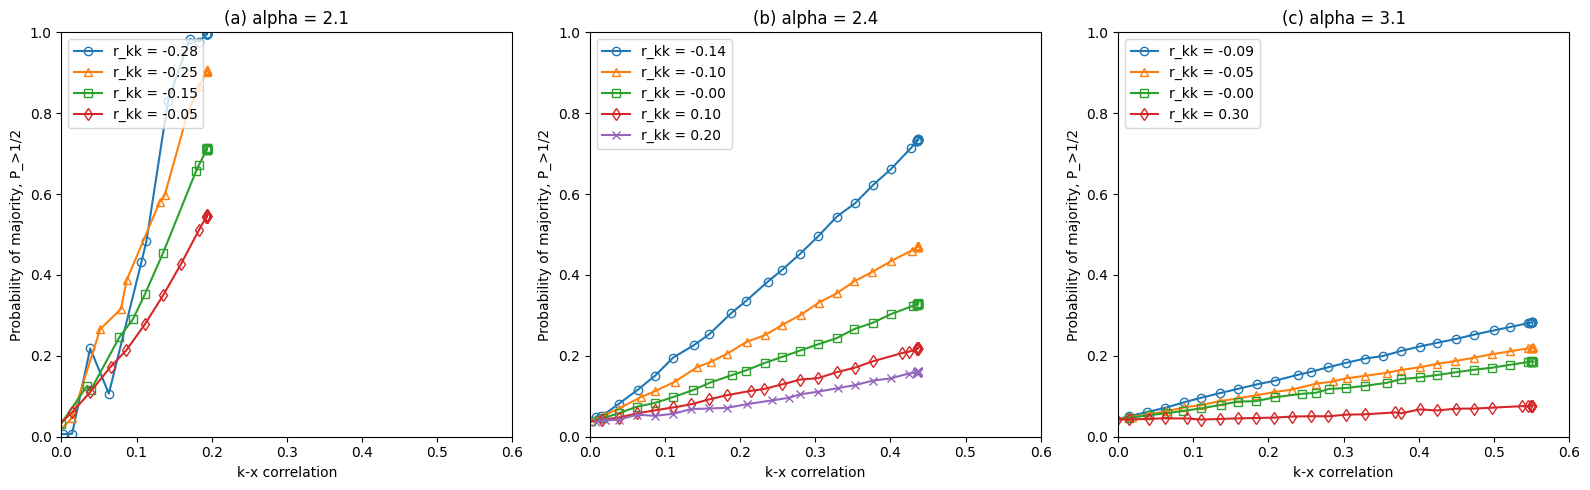

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
markers = ['o', '^', 's', 'd', 'x']

for i, alpha in enumerate(alphas):
    ax = axes[i]
    for j, curve in enumerate(results[alpha]):
        r_str = f"r_kk = {curve['r_actual']:.2f}"
        data = sorted(curve['data'], key=lambda d: d[0])
        x = [d[0] for d in data]
        y = [d[1] for d in data]
        ax.plot(x, y, marker=markers[j % len(markers)], label=r_str, fillstyle='none')
        
    ax.set_title(f'({"abc"[i]}) alpha = {alpha}')
    ax.set_xlabel('k-x correlation')
    ax.set_ylabel('Probability of majority, P_>1/2')
    ax.legend(loc='upper left')
    
    ax.grid(False) 
    
    ax.set_xlim(0, 0.6)
    ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.show()

### Simulación Erdos-Renyi

In [ ]:
mean_ks = [5.2, 2.5]
p_actives_er = [0.05, 0.10, 0.20]
target_assortativities_er = [-0.50, 0.00, 0.50]
target_rhos_er = np.linspace(0.0, 0.65, 25)

results_er = {}

print("Iniciando simulación para redes Erdős-Rényi...")

for mean_k in tqdm(mean_ks, desc="Progreso (<k>)"):
    results_er[mean_k] = {}
    G_base_er = generate_erdos_renyi_network(N, mean_k)
    G_base_er = nx.MultiGraph(G_base_er)
    
    for p_act in p_actives_er:
        results_er[mean_k][p_act] = []
        
        for target_r in target_assortativities_er:
            G_r = G_base_er.copy()
            actual_r = edge_rewiring(G_r, target_r=target_r, max_steps=15000)
            
            curve_data = []
            for trho in target_rhos_er:
                G_sim = G_r.copy()
                assign_initial_attributes(G_sim, p_act)
                actual_rho = attribute_swapping(G_sim, target_rho=trho, max_steps=15000)
                illusion = calculate_illusion(G_sim)
                curve_data.append((actual_rho, illusion))
                
            results_er[mean_k][p_act].append({'r_actual': actual_r, 'data': curve_data})
            
print("\nSimulación Erdős-Rényi completada.")

Iniciando simulación para redes Erdős-Rényi...


Progreso (<k>):   0%|          | 0/2 [00:00<?, ?it/s]

Red Erdős-Rényi generada (<k>=5.2):
 -> Grado prom. real: 5.18


Progreso (<k>):  50%|█████     | 1/2 [01:13<01:13, 73.12s/it]

Red Erdős-Rényi generada (<k>=2.5):
 -> Grado prom. real: 2.79


Progreso (<k>): 100%|██████████| 2/2 [01:56<00:00, 58.43s/it]


Simulación Erdős-Rényi completada.


### Visualización Erdos-Renyi

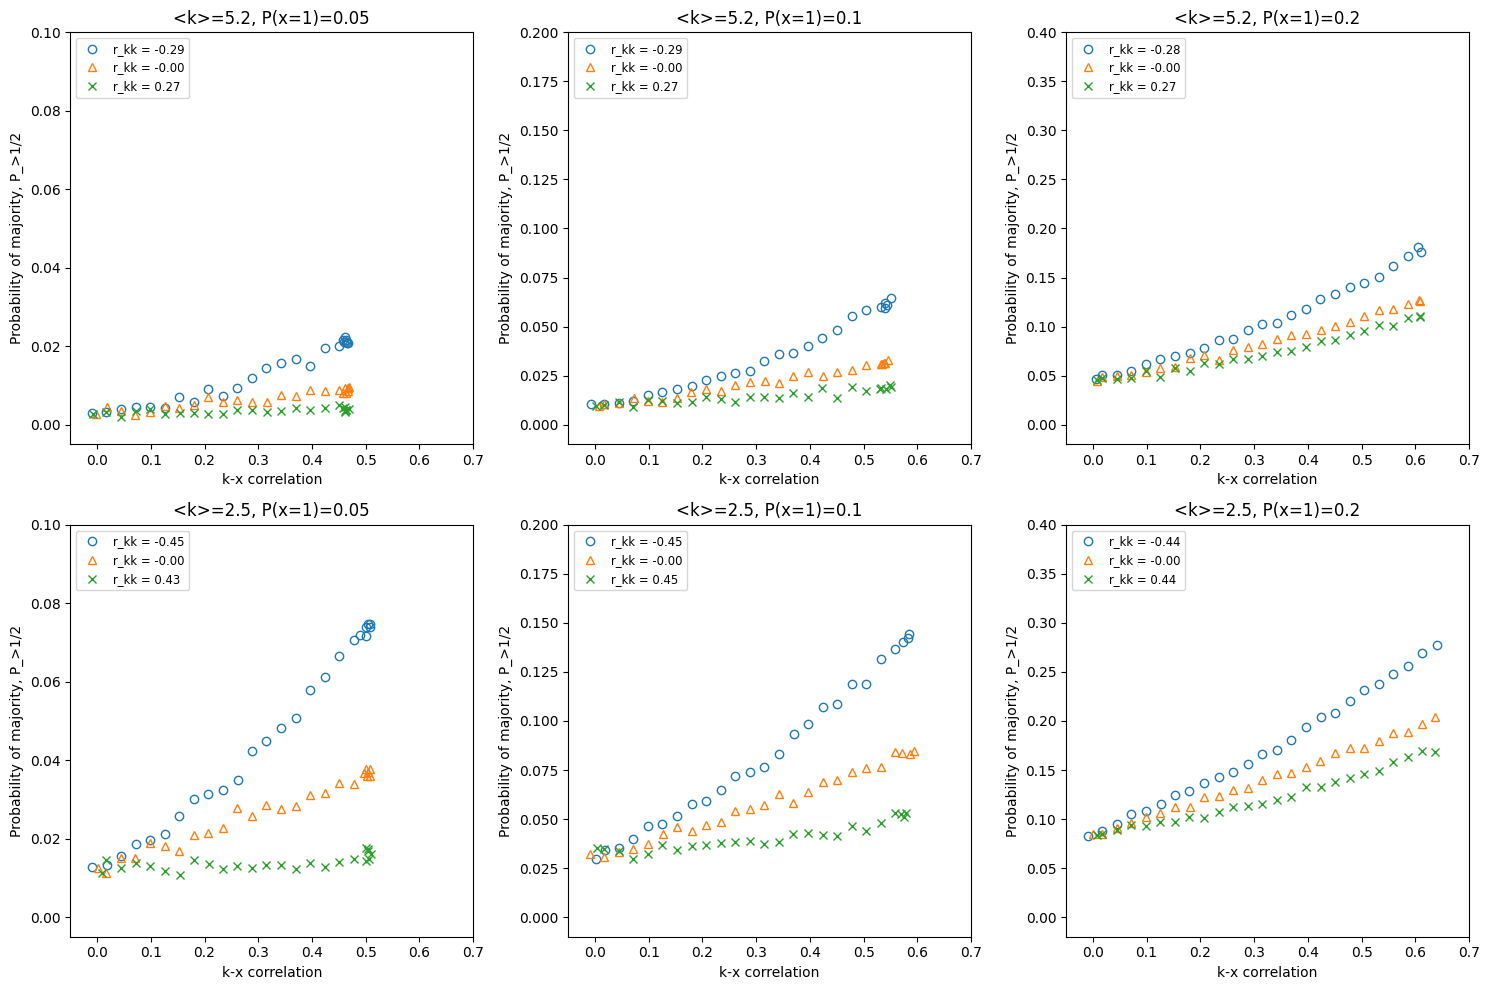

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
markers_er = ['o', '^', 'x']

for i, mean_k in enumerate(mean_ks):
    for j, p_act in enumerate(p_actives_er):
        ax = axes[i, j]
        for k_idx, curve in enumerate(results_er[mean_k][p_act]):
            r_str = f"r_kk = {curve['r_actual']:.2f}"
            data = sorted(curve['data'], key=lambda d: d[0])
            x = [d[0] for d in data]
            y = [d[1] for d in data]
            
            # En el paper, las curvas ER a veces son solo marcadores sin línea contínua
            ax.plot(x, y, marker=markers_er[k_idx % len(markers_er)], label=r_str, fillstyle='none', linestyle='')
        
        ax.set_title(f'<k>={mean_k}, P(x=1)={p_act}')
        ax.set_xlabel('k-x correlation')
        ax.set_ylabel('Probability of majority, P_>1/2')
        ax.legend(loc='upper left', fontsize='small')
        ax.grid(False)
        
        # Ajustar límites Y dinámicamente como en la Fig 3 del paper
        if p_act == 0.05:
            ax.set_ylim(-0.005, 0.1)
        elif p_act == 0.10:
            ax.set_ylim(-0.01, 0.2)
        else:
            ax.set_ylim(-0.02, 0.4)
            
        ax.set_xlim(-0.05, 0.7)

plt.tight_layout()
plt.show()

### Conclusión

Podemos observar lo leído en el paper. En una red de libre escala muy pocos nodos son hubs, y al activarlos, permitimos que esta minoría adopte el atributo. Al usar attribute swapping para forzar alta correlación grado-atributo, permitimos que una minoría global domine la visibilidad local, dando el espejismo de mayoría.

Con los resultados observamos que el espejismo es mas fuerte entre más heterogénea es la red. Esto se debe a que entre menor igualdad (menor alpha) hay hubs mucho mas grandes, por lo tanto el espejismo abarca un mayor porcentaje de la población. Esto se observa muy marcadamente al comparar el primer gráfico con alpha = 2.1 con el tercer grafico, con alpha 3.1. 

También, observamos que el principal modulador de la ilusión es la asortatividad, ya que en redes disasortativas (r<0) los hubs se enlazan más con nodos de bajo grado, disparando la percepción de mayoría, mientras que en redes asortativas (r>0) los hubs tienden a conectarse entre sí, lo que minimiza el impacto global.

Además, al simular redes aleatorias con Erdos Renyi se puede notar que el espejismo se reduce drasticamente.

Los graficos generados por mi cumplen con las mismas observaciones leidas en el paper, pero los graficos difieren un poco. esto se debe a que 

## c) Replique los experimentos generados con redes reales. Concluya.


### Configuración Entorno

In [ ]:
import pandas as pd
import json

### Carga y limpieza de redes

In [ ]:
def clean_graph(G):
    G = nx.Graph(G)
    G.remove_edges_from(nx.selfloop_edges(G))
    components = sorted(nx.connected_components(G), key=len, reverse=True)
    return G.subgraph(components[0]).copy()

# --- 1. Red ca-AstroPh ---
print("Cargando ca-AstroPh...")
G_astro_raw = nx.read_edgelist('data/ca-AstroPh.txt', comments='#')
G_astro = clean_graph(G_astro_raw)
r_astro = nx.degree_assortativity_coefficient(G_astro)
print(f"AstroPh - Nodos LCC: {G_astro.number_of_nodes()}, Aristas: {G_astro.number_of_edges()}")
print(f"AstroPh - Asortatividad base (r_kk): {r_astro:.4f}\n")

# --- 2. Red GitHub ---
print("Cargando GitHub...")
G_git_raw = nx.Graph()

# Cargar nodos base
df_target = pd.read_csv('data/git_target.csv')
G_git_raw.add_nodes_from(df_target['id'].astype(str))

# CORRECCIÓN: Lectura correcta de pares [u, v] desde el JSON
with open('data/git_edges.json', 'r', encoding='utf-8') as f:
    edges_dict = json.load(f)
    for key, edge_list in edges_dict.items():
        # Cada item en edge_list es un par [u, v]
        for u, v in edge_list:
            G_git_raw.add_edge(str(u), str(v))

G_git = clean_graph(G_git_raw)
r_git = nx.degree_assortativity_coefficient(G_git)
print(f"GitHub - Nodos LCC: {G_git.number_of_nodes()}, Aristas: {G_git.number_of_edges()}")
print(f"GitHub - Asortatividad base (r_kk): {r_git:.4f}")

Cargando ca-AstroPh...
AstroPh - Nodos LCC: 17903, Aristas: 196972
AstroPh - Asortatividad base (r_kk): 0.2013

Cargando GitHub...
GitHub - Nodos LCC: 957, Aristas: 316857
GitHub - Asortatividad base (r_kk): 0.0102


### Algoritmo de Manipulación

In [ ]:
def attribute_swapping(G, target_rho, max_steps=100000, tol=0.01):
    active_set = set(n for n, attr in G.nodes(data=True) if attr['x'] == 1)
    inactive_set = set(G.nodes()) - active_set
    active_list = list(active_set)
    inactive_list = list(inactive_set)
    
    degree_dict = dict(G.degree())
    current_rho = calculate_rhokx(G)
    
    if abs(current_rho - target_rho) < tol:
        return current_rho

    # Cálculo de constante de proporcionalidad (C_rho) para actualización O(1)
    nodes_list = list(G.nodes())
    k_array = np.array([degree_dict[n] for n in nodes_list])
    x_array = np.array([G.nodes[n]['x'] for n in nodes_list])
    
    sigma_k = np.std(k_array)
    sigma_x = np.std(x_array)
    if sigma_k == 0 or sigma_x == 0: return 0.0
    
    P_x1 = np.mean(x_array)
    C_rho = P_x1 / (sigma_x * sigma_k * len(active_list))

    for step in range(max_steps):
        if abs(current_rho - target_rho) < tol:
            break
            
        idx_a = random.randrange(len(active_list))
        idx_i = random.randrange(len(inactive_list))
        v_active = active_list[idx_a]
        v_inactive = inactive_list[idx_i]
        
        k_a = degree_dict[v_active]
        k_i = degree_dict[v_inactive]
        
        if (target_rho > current_rho and k_i > k_a) or (target_rho < current_rho and k_a > k_i):
            # Intercambiar estados
            G.nodes[v_active]['x'] = 0
            G.nodes[v_inactive]['x'] = 1
            
            # Actualizar listas eficientemente O(1)
            active_list[idx_a] = v_inactive
            inactive_list[idx_i] = v_active
            
            # Actualización O(1) de la métrica
            current_rho += C_rho * (k_i - k_a)
            
    return calculate_rhokx(G) # Retornar cálculo exacto final

### *Funciones de Asignación y Medición idénticas a la Parte b

### Simulación

In [ ]:
fractions = [0.05, 0.10, 0.20, 0.30]
target_rhos = np.linspace(0.0, 0.8, 25)

networks = {
    'AstroPh': {'G': G_astro, 'r': r_astro},
    'GitHub': {'G': G_git, 'r': r_git}
}

results = {name: {p: [] for p in fractions} for name in networks}

for net_name, net_data in networks.items():
    G_base = net_data['G']
    for p_active in fractions:
        print(f"\nProcesando {net_name} con P(x=1)={p_active}")
        for trho in tqdm(target_rhos, desc=f"{net_name} p={p_active}"):
            G_sim = G_base.copy()
            assign_initial_attributes(G_sim, p_active)
            actual_rho = attribute_swapping(G_sim, target_rho=trho, max_steps=200000)
            illusion = calculate_illusion(G_sim)
            results[net_name][p_active].append((actual_rho, illusion))

print("\nSimulación completada.")


Procesando AstroPh con P(x=1)=0.05


AstroPh p=0.05: 100%|██████████| 25/25 [00:16<00:00,  1.49it/s]



Procesando AstroPh con P(x=1)=0.1


AstroPh p=0.1: 100%|██████████| 25/25 [00:20<00:00,  1.23it/s]



Procesando AstroPh con P(x=1)=0.2


...


Procesando GitHub con P(x=1)=0.2


GitHub p=0.2: 100%|██████████| 25/25 [00:30<00:00,  1.21s/it]



Procesando GitHub con P(x=1)=0.3


GitHub p=0.3:   8%|▊         | 2/25 [00:02<00:24,  1.07s/it]


KeyboardInterrupt: 

### Visualización

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) 
styles = {
    0.30: {'marker': 'o', 'color': 'blue', 'label': 'P(x=1)=0.3'},
    0.20: {'marker': '^', 'color': 'red', 'label': 'P(x=1)=0.2'},
    0.10: {'marker': 's', 'color': 'green', 'label': 'P(x=1)=0.1'},
    0.05: {'marker': 'x', 'color': 'black', 'label': 'P(x=1)=0.05'}
}

for i, (net_name, net_data) in enumerate(networks.items()):
    ax = axes[i]
    for p_active in fractions:
        curve = results[net_name][p_active]
        # Ordenar por el X real obtenido por consistencia al graficar
        curve = sorted(curve, key=lambda d: d[0])
        x = [d[0] for d in curve]
        y = [d[1] for d in curve]
        
        sty = styles[p_active]
        # fillstyle='none' imita los marcadores sin relleno del paper
        fs = 'none' if p_active != 0.05 else 'full'
        ax.plot(x, y, marker=sty['marker'], color=sty['color'], 
                label=sty['label'], fillstyle=fs, linestyle='')
        
    ax.set_title(f'({"ab"[i]}) {net_name}')
    ax.set_xlabel('k-x correlation')
    ax.set_ylabel('Probability of majority, P_{>1/2}')
    ax.legend(loc='upper left', fontsize='small')
    
    ax.grid(False) 
    ax.set_ylim(-0.05, 0.85)
    ax.set_xlim(-0.05, 0.85)

plt.tight_layout()
plt.show()

### Conclusión

Podemos observar que el fenómeno del espejismo de la mayoría se comporta distinto para las dos redes escogidas. Esto se valida que la asortatividad puede amplificar o bloquear la distorsión de la realidad en la red. 

En la red de github, la asortatividad es mucho mas baja que en AstroPH, tendiendo hacia lo disasortativo. Esto significa que los hubs suelen estar mas conectados con usuarios de bajo grado, y cuando se vuelven activos contagian a los usuarios pequeños, haciendo crecer rápidamente la ilusión con pocos nodos activos.

En el caso de AstroPH la red es fuertemente asortativa, por lo que los hubs tienden a conectarse entre sí, creando un núcleo rich-club. Cuando activamos los hubs, el atributo se queda en el centro, y los nodos periféricos (mayoría) están protegidos del efecto ya que no están conectados con hubs activos.